# Notebook para el Copiloto Virtual

### Elaborado por Alvaro Zambrana Sejas
### Universidad Mayor de San Simón
### 2024

Entrenamiento(Fine Tuning) local con YOLOv8 utilizando un conjunto de datos personalizado.

Requirements:
- Anaconda3
- Python 3.10 

Configurar:
```
conda create -n copiloto-virtual python=3.10
conda activate copiloto-virtual
``` 

## Verificar la versión de Python y las librerías instaladas

In [21]:
!python --version

Python 3.10.16


In [22]:
!nvidia-smi

Thu Mar 13 09:26:11 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 572.60                 Driver Version: 572.60         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3090      WDDM  |   00000000:01:00.0  On |                  N/A |
| 36%   34C    P8             28W /  350W |    2217MiB /  24576MiB |     25%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Configurar el entorno

In [23]:
import os
%cd ..

HOME = os.getcwd()
parent_dir = os.path.dirname(HOME)
print(f'HOME: {HOME}')

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

C:\Users\Alvaro\PycharmProjects\copiloto-virtual
HOME: C:\Users\Alvaro\PycharmProjects\copiloto-virtual


In [15]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.5.1+cu124
Uninstalling torch-2.5.1+cu124:
  Successfully uninstalled torch-2.5.1+cu124
Found existing installation: torchvision 0.20.1+cu124
Uninstalling torchvision-0.20.1+cu124:
  Successfully uninstalled torchvision-0.20.1+cu124
Found existing installation: torchaudio 2.5.1+cu124
Uninstalling torchaudio-2.5.1+cu124:
  Successfully uninstalled torchaudio-2.5.1+cu124


In [17]:
# reiniciar el kernel después de ejecutar la celda anterior
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126


In [20]:
import torch
print(torch.cuda.is_available())  # Should return True
print(torch.cuda.get_device_name(0))
print(torch.cuda.current_device())
print(torch.__version__)


True
NVIDIA GeForce RTX 3090
0
2.6.0+cu126


In [21]:
!pip uninstall -y ultralytics

Found existing installation: ultralytics 8.2.103
Uninstalling ultralytics-8.2.103:
  Successfully uninstalled ultralytics-8.2.103


In [22]:
# Instalar la revisión correspondiente a YOLOv8
!pip install ultralytics==8.2.103

  Using cached ultralytics-8.2.103-py3-none-any.whl.metadata (39 kB)
Using cached ultralytics-8.2.103-py3-none-any.whl (875 kB)


In [23]:
!pip install huggingface_hub

In [24]:
!yolo -version

8.2.103


## Prueba de inferencia utilizando el model de YOLOv8 pre-entrenado

In [25]:
!cd {HOME}
!yolo task=detect mode=predict conf=0.25 save=True model={HOME}/weights/yolov8n.pt source=".\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg" device=0 project="resultados\\YOLOv8" name="prueba_inferencia" exist_ok=True

Ultralytics YOLOv8.2.103 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
YOLOv8n summary (fused): 168 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs

image 1/1 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg: 640x640 1 person, 2 cars, 1 bus, 2 trucks, 9.0ms
Speed: 5.0ms preprocess, 9.0ms inference, 90.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to resultados\YOLOv8\prueba_inferencia
ðŸ’¡ Learn more at https://docs.ultralytics.com/modes/predict


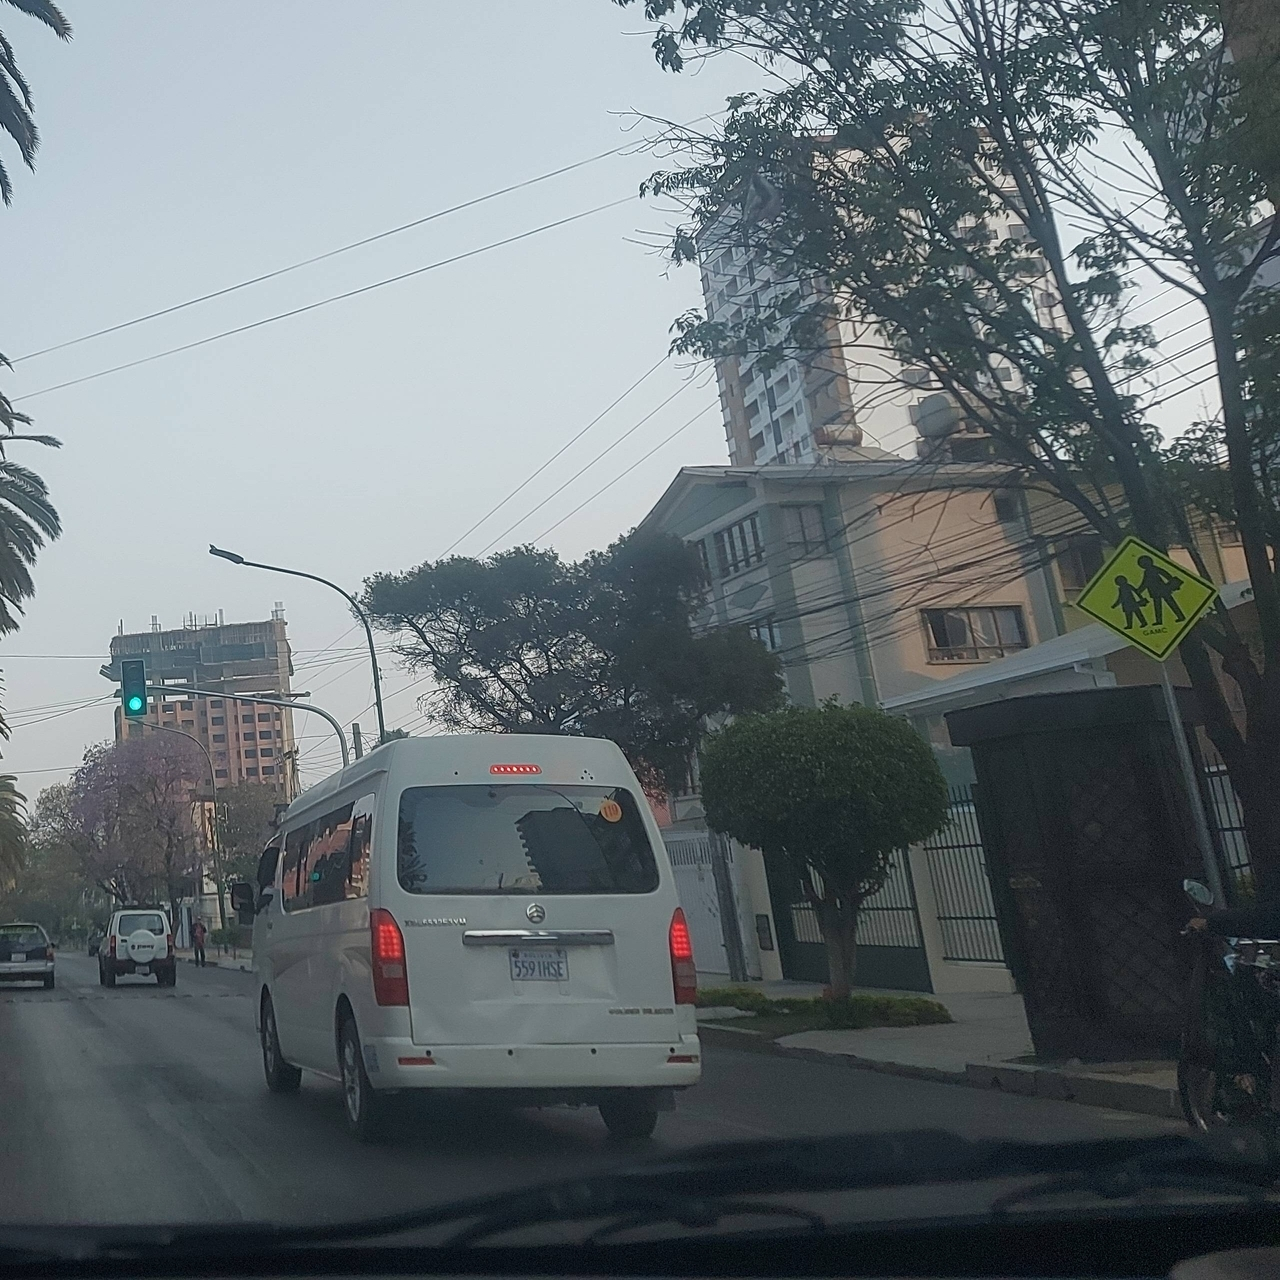

In [26]:
from IPython.display import Image

Image(filename=f".\\dataset\\processed\\yolo_signals_cbba_with_augmented_data\\test\\images\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

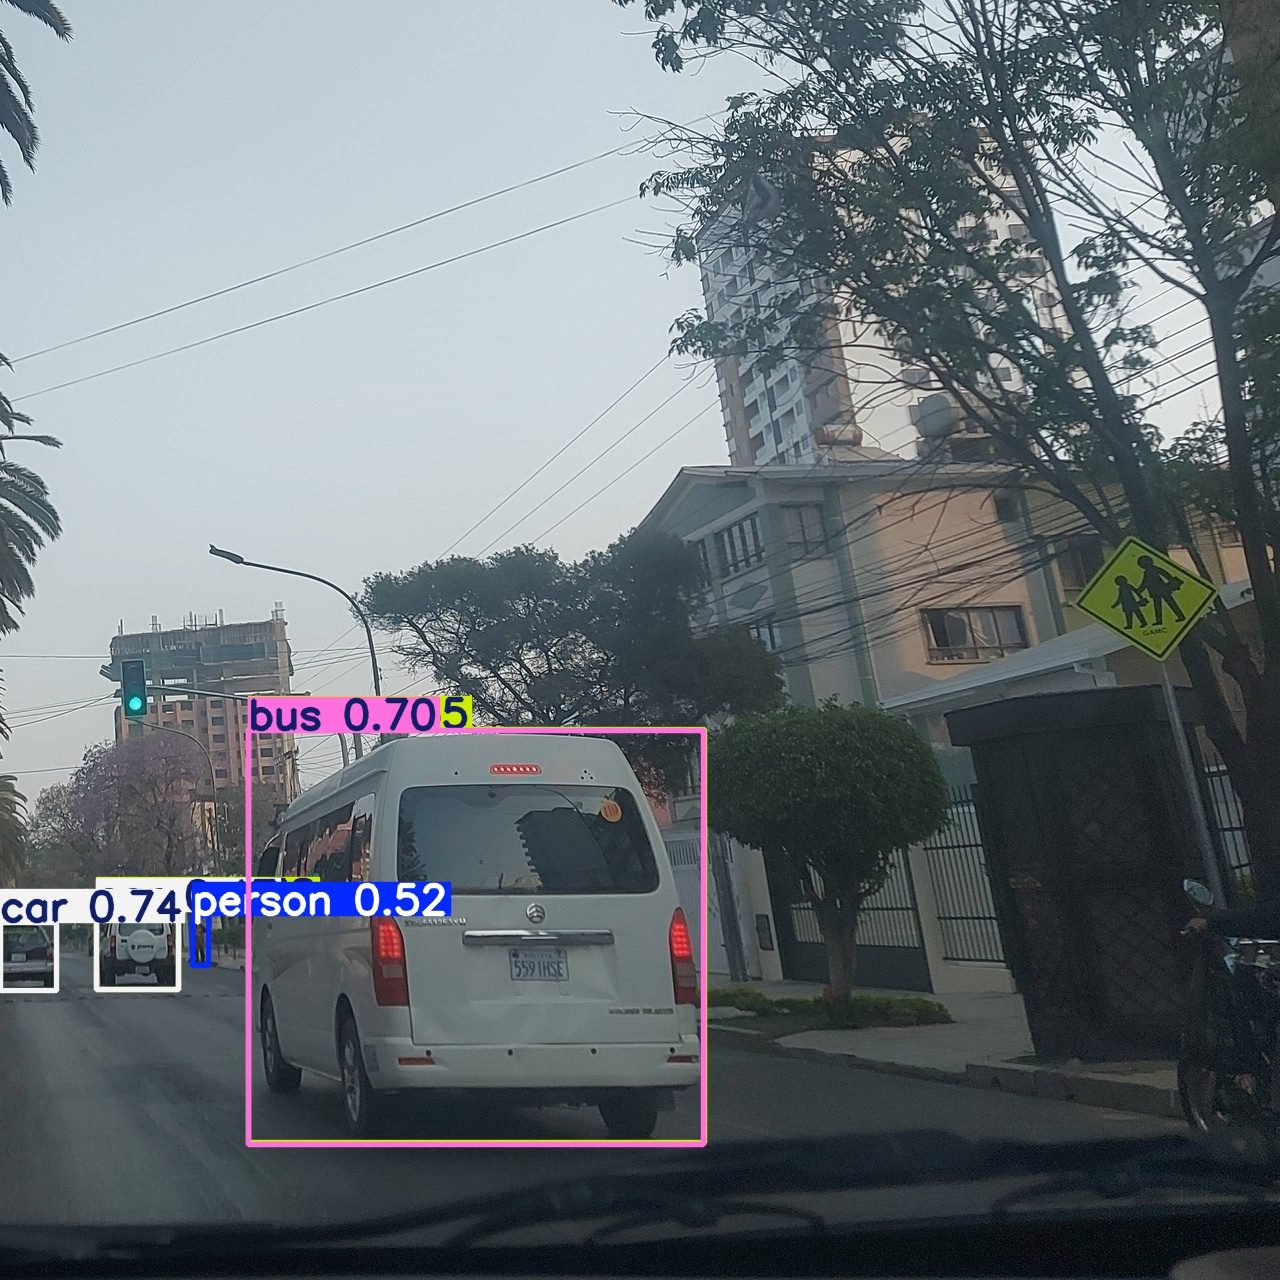

In [28]:
from IPython.display import Image

# Display the detected image
Image(filename=f".\\resultados\\YOLOv8\\prueba_inferencia\\2024_09_08_17_28_09_150_-0400_1280x1280.right-region.jpg", height=640)

# Entrenamiento con Fine Tuning de YOLOv8 utilizando un conjunto de datos personalizado

In [29]:
import torch
print(torch.cuda.is_available())

True


In [30]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Wed_Aug_14_10:26:51_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.68
Build cuda_12.6.r12.6/compiler.34714021_0


In [31]:
torch.version.cuda

'12.6'

In [32]:
import ultralytics

ultralytics.checks()

Ultralytics YOLOv8.2.103  Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
Setup complete  (12 CPUs, 31.9 GB RAM, 924.7/953.0 GB disk)


In [33]:
!pip install albumentations==1.4

In [5]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=10 batch=16 plots=True model={HOME}/weights/yolov8n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 imgsz=640 project="resultados\\YOLOv8" name="10_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
New https://pypi.org/project/ultralytics/8.3.89 available ðŸ˜ƒ Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolov8n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=10, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=0, workers=8, project=resultados\\YOLOv8, name=10_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4


train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]
train: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\train\labels.cache... 4881 images, 168 backgrounds, 0 corrupt: 100%|##########| 4881/4881 [00:00<?, ?it/s]

val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]
val: Scanning C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\val\labels.cache... 235 images, 0 backgrounds, 0 corrupt: 100%|##########| 235/235 [00:00<?, ?it/s]

  0

In [9]:
os.environ['YOLO_VERBOSE'] = 'True'
os.environ['NO_ALBUMENTATIONS_UPDATE'] = '1'

%cd {HOME}

!yolo task=detect mode=train epochs=300 batch=16 plots=True model={HOME}/weights/yolov8n.pt data={HOME}/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml device=0 lr0=1e-4 patience=20 imgsz=1280 project="resultados\\YOLOv8" name="300_epochs" exist_ok=True

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition
New https://pypi.org/project/ultralytics/8.3.89 available ðŸ˜ƒ Update with 'pip install -U ultralytics'
Ultralytics YOLOv8.2.103 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
engine\trainer: task=detect, mode=train, model=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/weights/yolov8n.pt, data=C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition/dataset/processed/yolo_signals_cbba_with_augmented_data/data.yaml, epochs=300, time=None, patience=20, batch=16, imgsz=1280, save=True, save_period=-1, cache=False, device=0, workers=8, project=resultados\\YOLOv8, name=300_epochs, exist_ok=True, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

     60/300      7.93G     0.9575     0.5024      1.025         26       1280:  11%|#1        | 34/306 [00:09<01:08,  3.95it/s]
     60/300      7.93G     0.9575     0.5024      1.025         26       1280:  11%|#1        | 35/306 [00:09<01:12,  3.75it/s]
     60/300      7.93G     0.9568     0.4997      1.025         19       1280:  11%|#1        | 35/306 [00:09<01:12,  3.75it/s]
     60/300      7.93G     0.9568     0.4997      1.025         19       1280:  12%|#1        | 36/306 [00:09<01:10,  3.85it/s]
     60/300      7.93G      0.956      0.498      1.023         18       1280:  12%|#1        | 36/306 [00:09<01:10,  3.85it/s]
     60/300      7.93G      0.956      

# Pruebas de Inference con el modelo entrenado

In [10]:
!yolo task=detect mode=predict conf=0.25 imgsz=1280 save=True show=True model={HOME}\resultados\YOLOv8\300_epochs\weights\best.pt source={HOME}\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\ device=0 project="resultados\\YOLOv8" name="prueba_inferencia_300_epochs" exist_ok=True 

WARNING âš ï¸� Environment does not support cv2.imshow() or PIL Image.show()
OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\highgui\src\window.cpp:1301: error: (-2:Unspecified error) The function is not implemented. Rebuild the library with Windows, GTK+ 2.x or Cocoa support. If you are on Ubuntu or Debian, install libgtk2.0-dev and pkg-config, then re-run cmake or configure script in function 'cvShowImage'

Ultralytics YOLOv8.2.103 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3090, 24575MiB)
Model summary (fused): 168 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

image 1/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_signals_cbba_with_augmented_data\test\images\2024_08_18_17_40_52_601_-0400_1280x1280.left-region.jpg: 1280x1280 1 zona-escolar, 1 prohibido-girar-izquierda, 9.0ms
image 2/116 C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\dataset\processed\yolo_sig

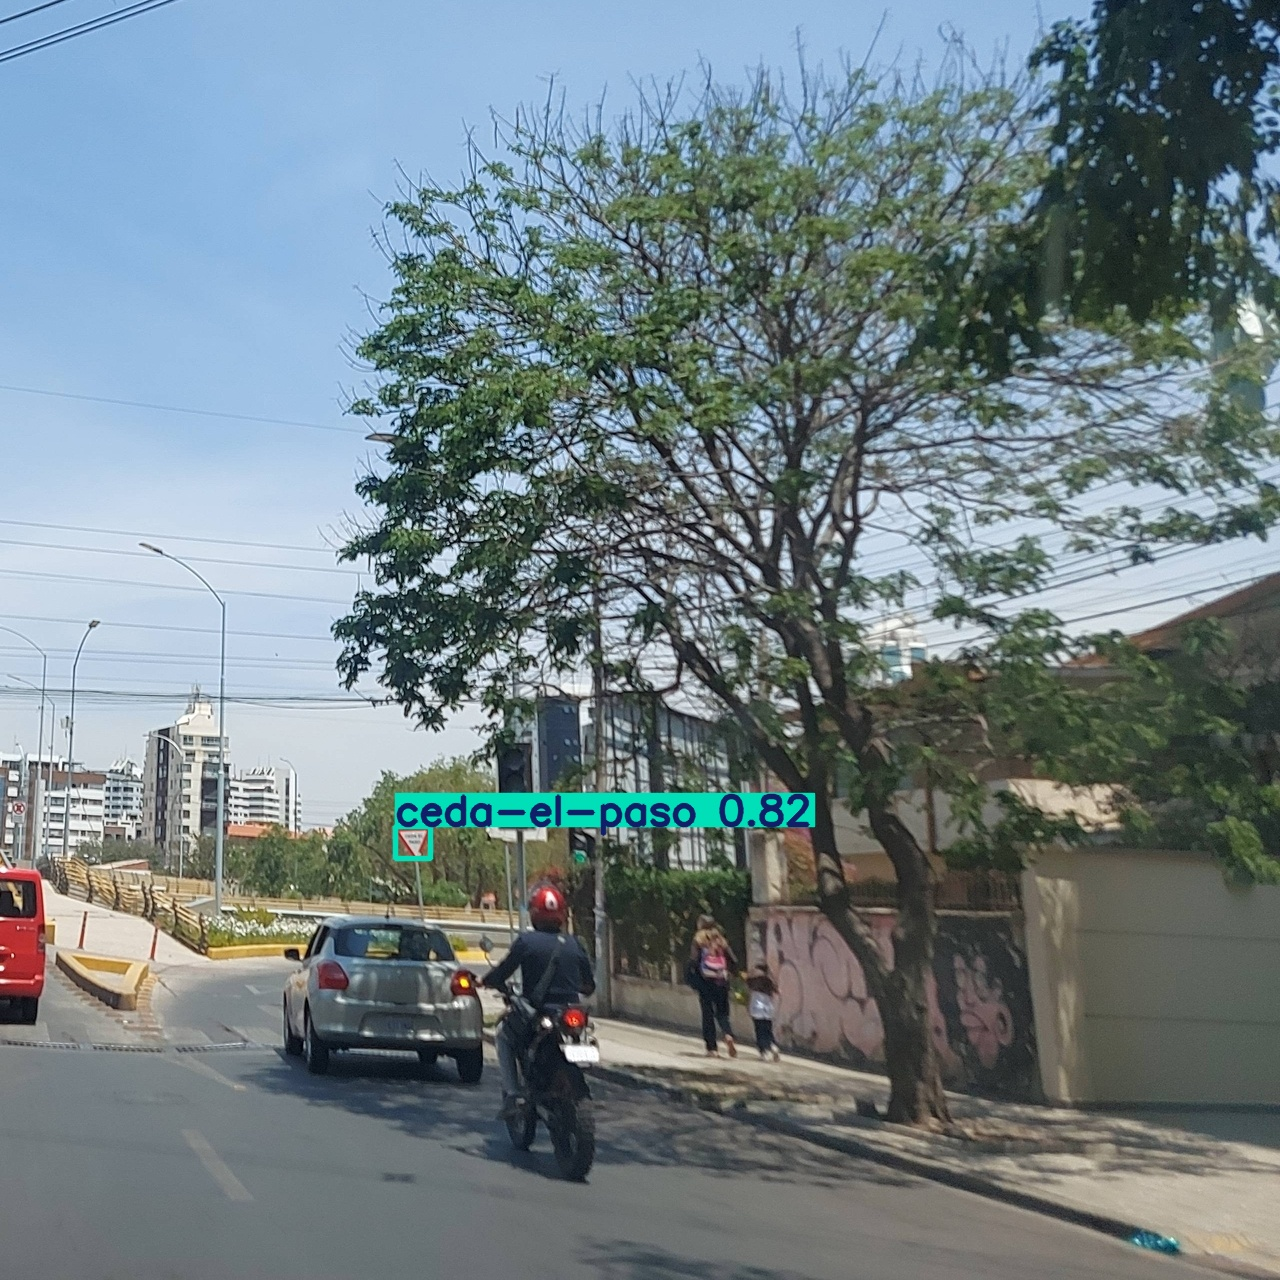

In [11]:
from IPython.display import Image
Image(filename=f"{HOME}\\resultados\YOLOv8\\prueba_inferencia_300_epochs\\2024_10_01_12_40_45_425_-0400_1280x1280.right-region.jpg", height=600)

## Matrices de Confusión

C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition


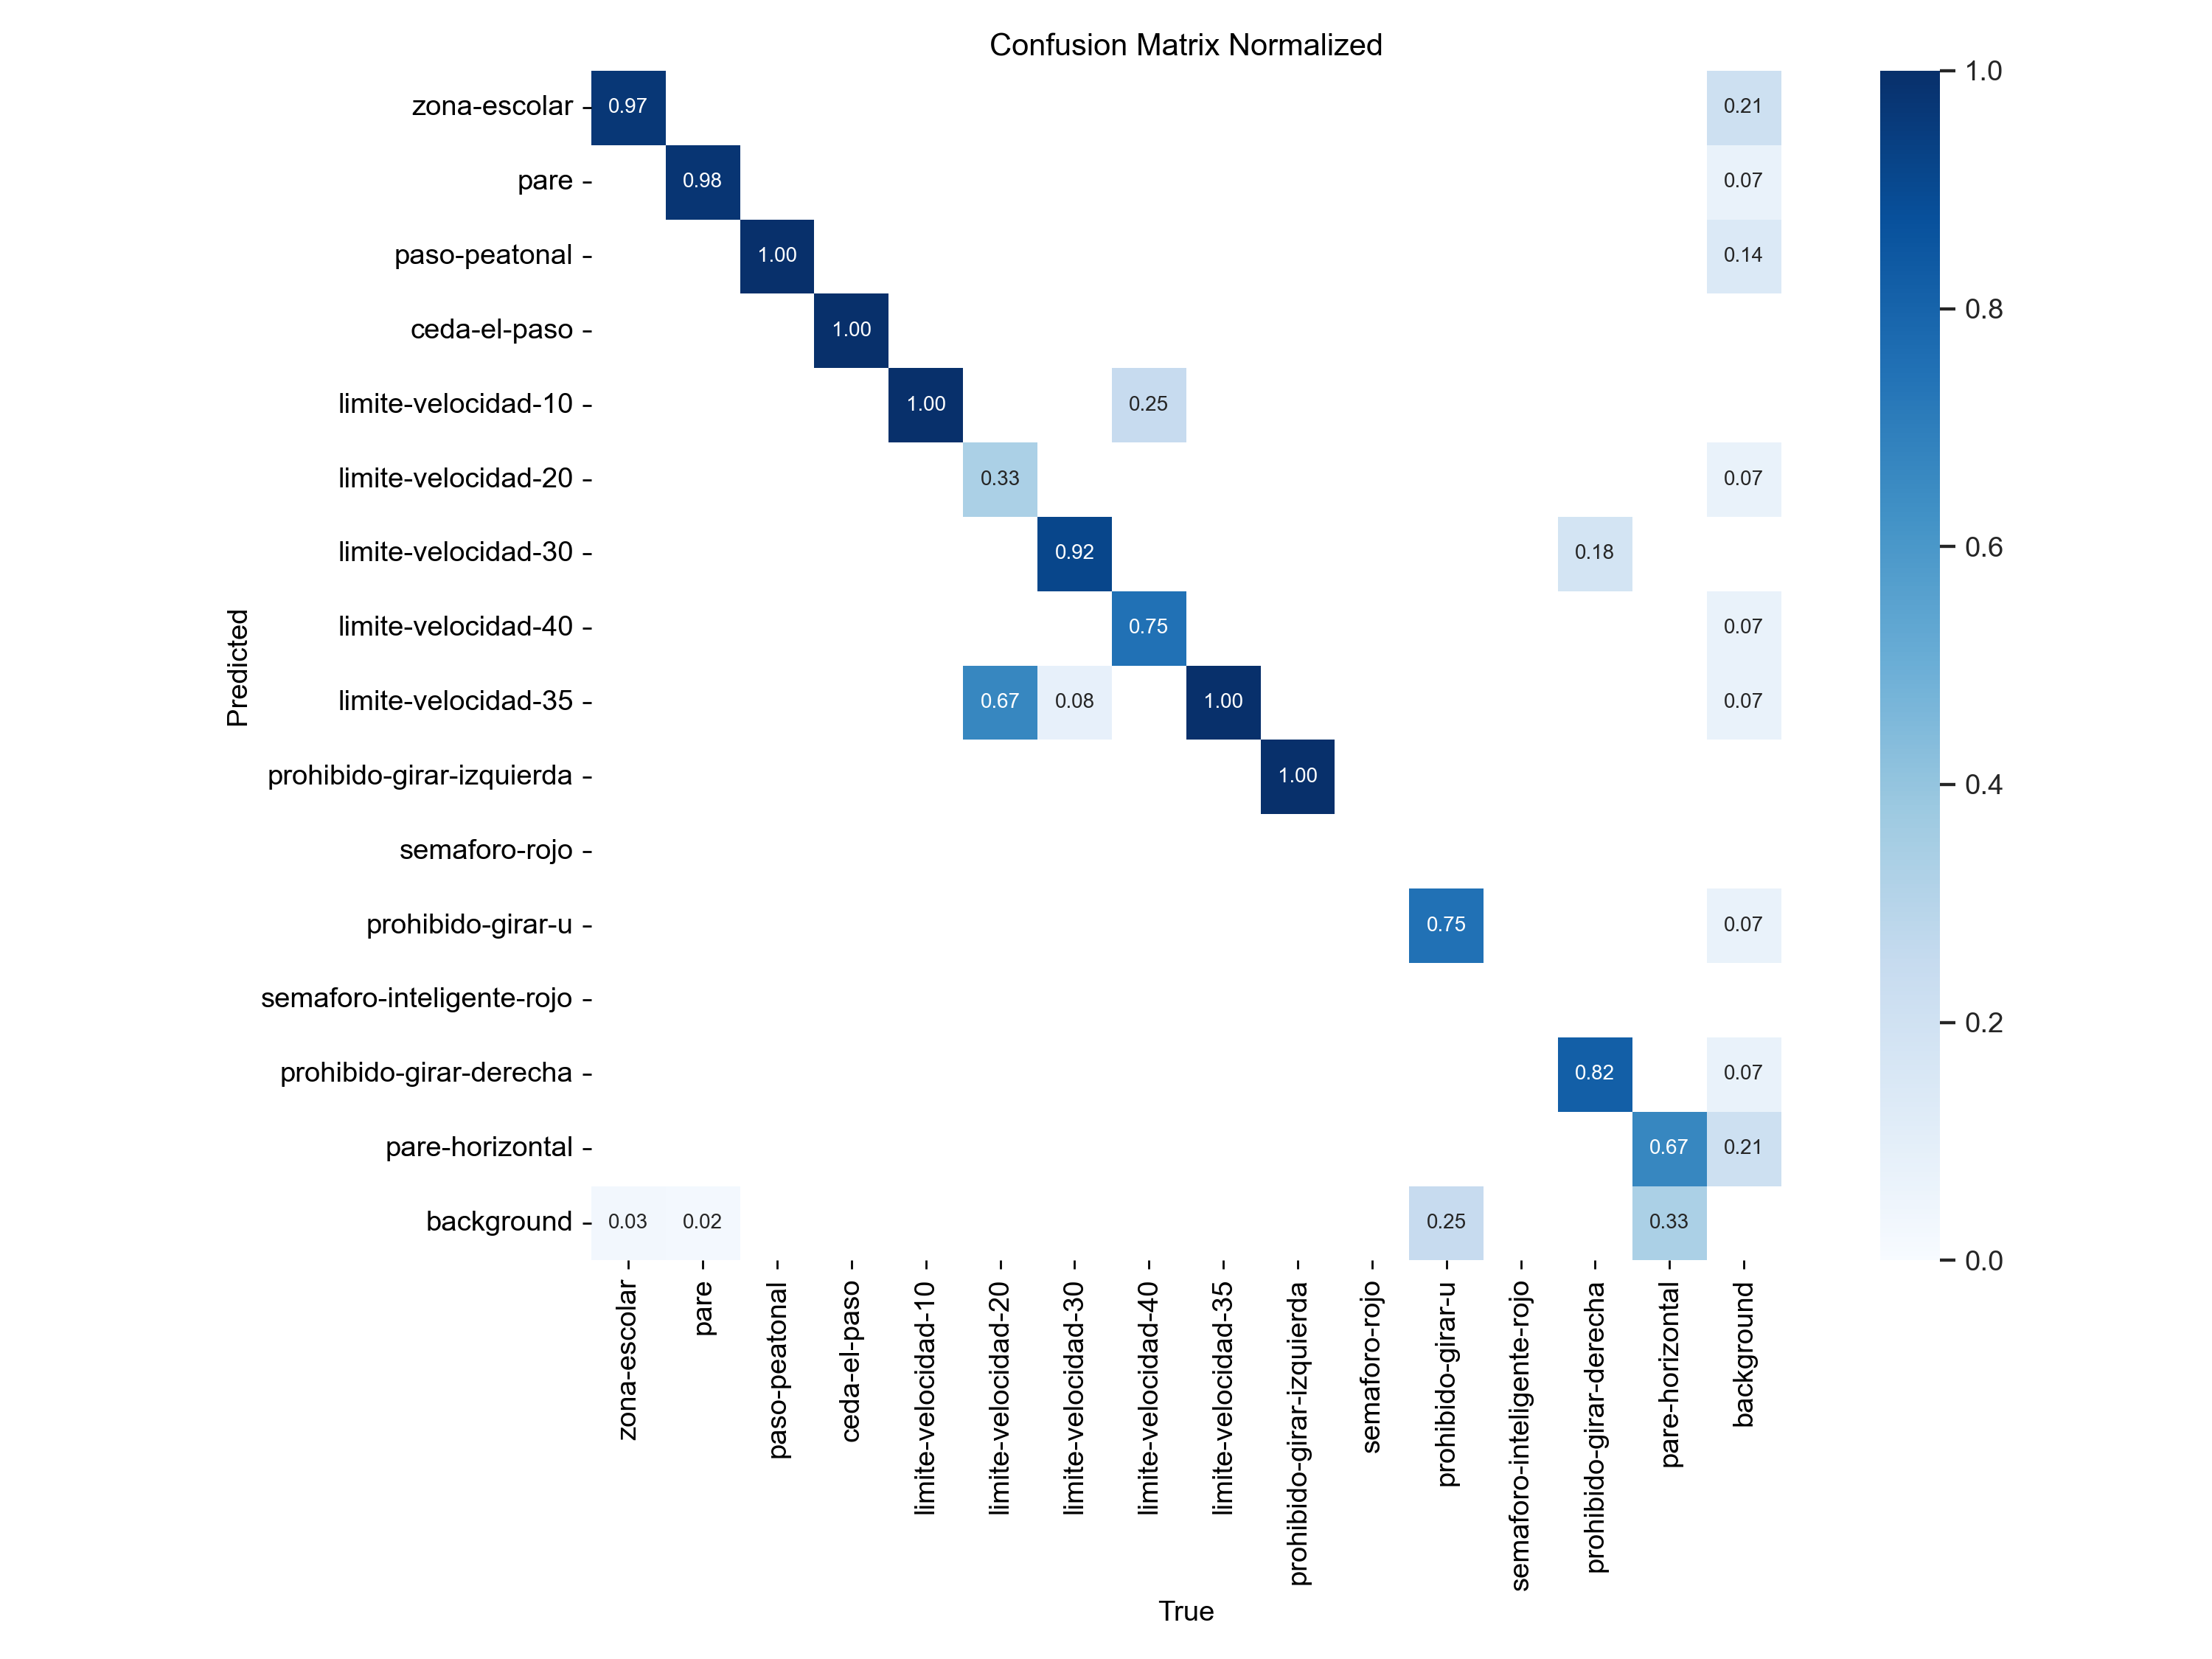

In [17]:
%cd {HOME}
Image(filename=f'{HOME}\\resultados\\YOLOv8\\300_epochs\\confusion_matrix_normalized.png', width=600)

## Exportar el mejor modelo

In [20]:
!yolo export model={HOME}/resultados/YOLOv8/300_epochs/weights/best.pt format=tflite imgsz=1280

Ultralytics YOLOv8.2.103 ðŸš€ Python-3.10.16 torch-2.6.0+cu126 CPU (Intel Core(TM) i7-8700 3.20GHz)
Model summary (fused): 168 layers, 3,008,573 parameters, 0 gradients, 8.1 GFLOPs

PyTorch: starting from 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv8\300_epochs\weights\best.pt' with input shape (1, 3, 1280, 1280) BCHW and output shape(s) (1, 19, 33600) (6.1 MB)

TensorFlow SavedModel: starting export with tensorflow 2.18.0...

ONNX: starting export with onnx 1.17.0 opset 19...
ONNX: slimming with onnxslim 0.1.34...
ONNX: export success âœ… 1.6s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv8\300_epochs\weights\best.onnx' (12.6 MB)
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.22.3...
TensorFlow SavedModel: export success âœ… 21.8s, saved as 'C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\resultados\YOLOv8\300_epochs\weights\best_saved_model' (3



  0%|          | 0.00/1.11M [00:00<?, ?B/s]
 34%|###3      | 384k/1.11M [00:00<00:00, 3.82MB/s]
100%|##########| 1.11M/1.11M [00:00<00:00, 7.31MB/s]

Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\calibration_image_sample_data_20x128x128x3_float32.npy...:   0%|          | 0/1 [00:00<?, ?file/s]
Unzipping calibration_image_sample_data_20x128x128x3_float32.npy.zip to C:\Users\Alvaro\PycharmProjects\copiloto-virtual\traffic-sign-recognition\calibration_image_sample_data_20x128x128x3_float32.npy...: 100%|##########| 1/1 [00:00<00:00, 83.34file/s]
I0000 00:00:1741870629.875431   26520 devices.cc:76] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
I0000 00:00:1741870629.876206   26520 single_machine.cc:361] Starting new session
W0000 00:00:1741870630.525168   26520 tf_tfl_flatbuffer_helpers.cc:365] Ignored o